## FAST LAP F1 PROJECT
#### By Sergio Baz Galicia

In [1]:
pip install fastf1 pandas scikit-learn xgboost matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


C:\Users\HP\anaconda3\Lib\site-packages\fastf1\plotting\_plotting.py:56: FutureWarning: The `misc_mpl_mods` argument was dropped from `.setup_mpl()` in version 3.6.0 and has no effect anymore. It will be removed in a future version of FastF1.
  warnings.warn(
req         WARNING 	DEFAULT CACHE ENABLED! (418.88 MB) C:\Users\HP\AppData\Local\Temp\fastf1
events      WARNING 	Correcting user input 'Qatar' to 'Qatar Grand Prix'
core           INFO 	Loading data for Qatar Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre s

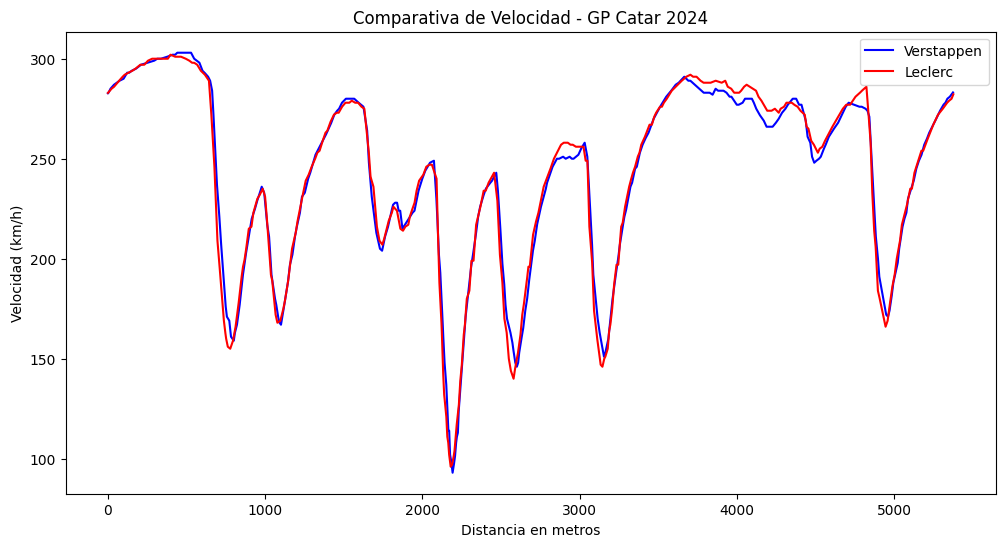

In [2]:
import fastf1
from fastf1 import plotting
import matplotlib.pyplot as plt

plotting.setup_mpl(mpl_timedelta_support=False, misc_mpl_mods=False)

# (Año, GP, Sesión 'R'=Carrera, 'Q'=Qualy)
session = fastf1.get_session(2024, 'Qatar', 'R')
session.load()

ver_lap = session.laps.pick_driver('VER').pick_fastest()
per_lap = session.laps.pick_driver('LEC').pick_fastest()

# distancia vs velocidad 
ver_tel = ver_lap.get_telemetry().add_distance()
per_tel = per_lap.get_telemetry().add_distance()

# Graficas 
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ver_tel['Distance'], ver_tel['Speed'], label='Verstappen', color='blue')
ax.plot(per_tel['Distance'], per_tel['Speed'], label='Leclerc', color='red')

ax.set_xlabel('Distancia en metros')
ax.set_ylabel('Velocidad (km/h)')
ax.set_title(f'Comparativa de Velocidad - GP Catar 2024')
ax.legend()
plt.show()

In [3]:

session = fastf1.get_session(2024, 'Saudi Arabia', 'Q')
session.load()

lap = session.laps.pick_driver('LEC').pick_fastest()
telemetry = lap.get_telemetry()

# EDA
print(telemetry.info())
print(telemetry.head())

core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '11', '14', '81', '4', '63', '44', '22', '18', '38', '23', '20', '3', '27', '77', '31', '10', '2', '24']
C:\Users\HP\anaconda3\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated a

<class 'fastf1.core.Telemetry'>
Index: 671 entries, 2 to 672
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype          
---  ------                 --------------  -----          
 0   Date                   671 non-null    datetime64[ns] 
 1   SessionTime            671 non-null    timedelta64[ns]
 2   DriverAhead            671 non-null    object         
 3   DistanceToDriverAhead  671 non-null    float64        
 4   Time                   671 non-null    timedelta64[ns]
 5   RPM                    671 non-null    float64        
 6   Speed                  671 non-null    float64        
 7   nGear                  671 non-null    int64          
 8   Throttle               671 non-null    float64        
 9   Brake                  671 non-null    bool           
 10  DRS                    671 non-null    int64          
 11  Source                 671 non-null    object         
 12  Distance               671 non-null    float64        
 13  R

core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '11', '14', '81', '4', '63', '44', '22', '18', '38', '23', '20', '3', '27', '77', '31', '10', '2', '24']
C:\Users\HP\anaconda3\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated a

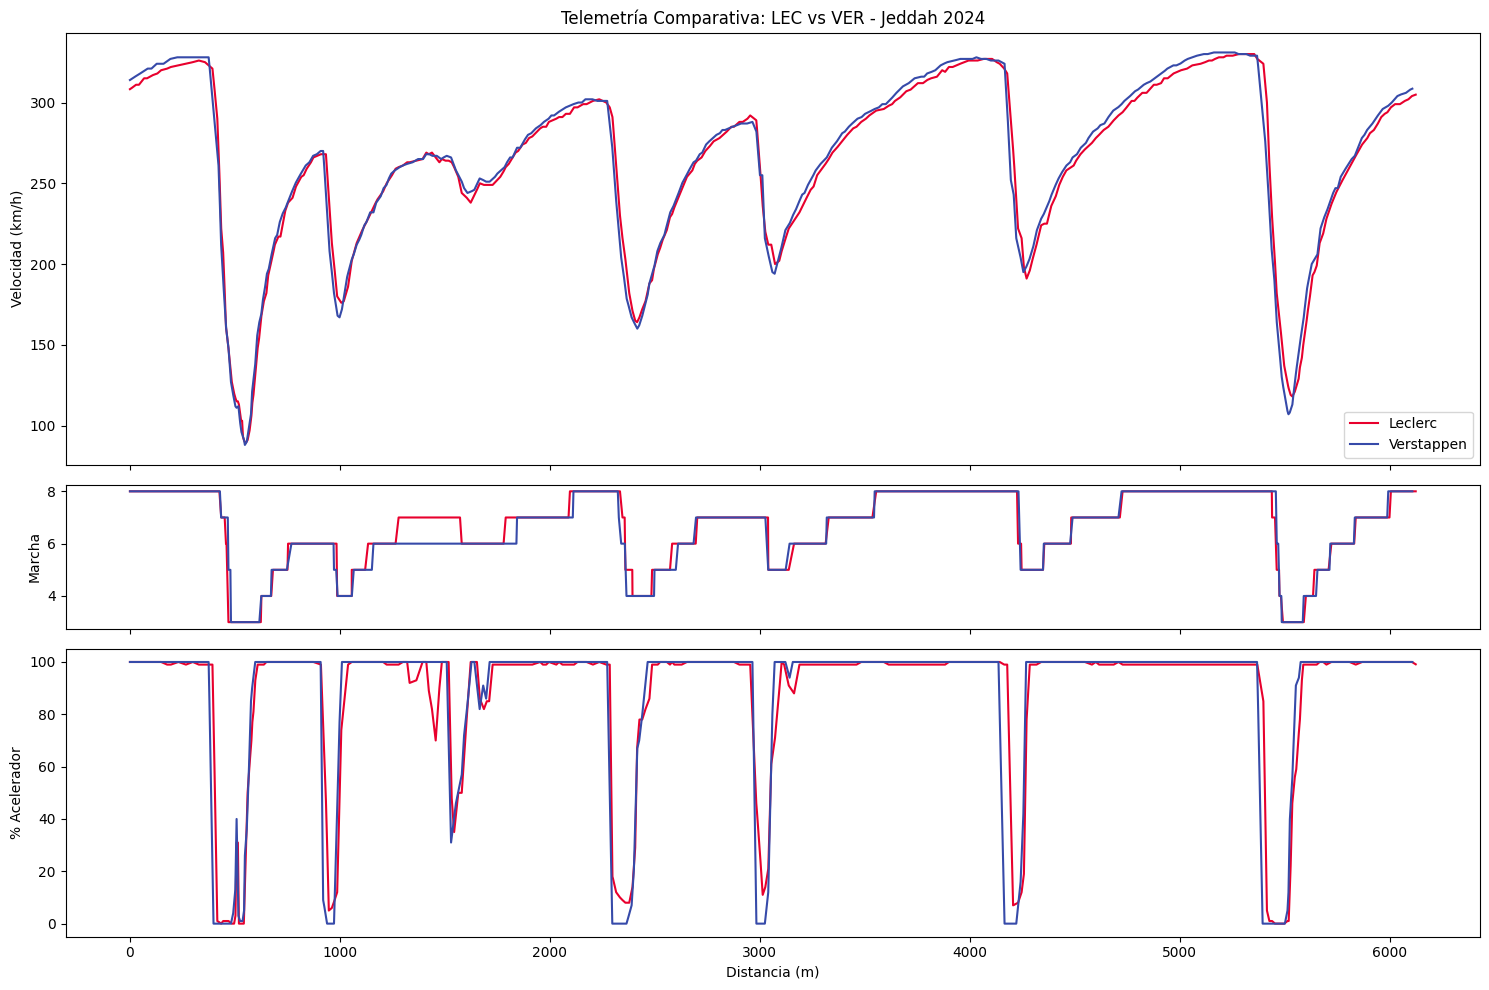

In [4]:
import fastf1
from fastf1 import plotting
import matplotlib.pyplot as plt

# Saudi Arabia Quali
session = fastf1.get_session(2024, 'Saudi Arabia', 'Q')
session.load()

# Leclerc vs Verstappen
laps_lec = session.laps.pick_driver('LEC').pick_fastest()
laps_ver = session.laps.pick_driver('VER').pick_fastest()

tel_lec = laps_lec.get_telemetry().add_distance()
tel_ver = laps_ver.get_telemetry().add_distance()

color_lec = plotting.get_team_color('FER', session)
color_ver = plotting.get_team_color('RBR', session)

# Dashboard
fig, ax = plt.subplots(3, 1, figsize=(15, 10), sharex=True, 
                       gridspec_kw={'height_ratios': [3, 1, 2]})

# Velocidad
ax[0].plot(tel_lec['Distance'], tel_lec['Speed'], color=color_lec, label='Leclerc')
ax[0].plot(tel_ver['Distance'], tel_ver['Speed'], color=color_ver, label='Verstappen')
ax[0].set_ylabel('Velocidad (km/h)')
ax[0].legend(loc='lower right')
ax[0].set_title('Telemetría Comparativa: LEC vs VER - Jeddah 2024')

# Gear
ax[1].plot(tel_lec['Distance'], tel_lec['nGear'], color=color_lec)
ax[1].plot(tel_ver['Distance'], tel_ver['nGear'], color=color_ver)
ax[1].set_ylabel('Marcha')

# Throttle
ax[2].plot(tel_lec['Distance'], tel_lec['Throttle'], color=color_lec)
ax[2].plot(tel_ver['Distance'], tel_ver['Throttle'], color=color_ver)
ax[2].set_ylabel('% Acelerador')
ax[2].set_xlabel('Distancia (m)')

# Ajustar diseño
plt.tight_layout()
plt.show()

## Applied Machine Learning with data from past GP


In [5]:
import fastf1
import pandas as pd

def get_ml_data(year, gp, session_type):
    s = fastf1.get_session(year, gp, session_type)
    s.load()
    laps = s.laps.pick_quicklaps().dropna(subset=['LapTime'])
    
    rows = []
    for _, lap in laps.iterrows():
        try:
            tel = lap.get_telemetry()
            rows.append({
                'Driver': lap['Driver'],
                'Compound': lap['Compound'],
                'TyreLife': lap['TyreLife'],
                'MaxSpeed': tel['Speed'].max(),
                'AvgThrottle': tel['Throttle'].mean(),
                'BrakeEvents': (tel['Brake'] == True).sum(),
                'LapTime': lap['LapTime'].total_seconds()
            })
        except: continue
    return pd.DataFrame(rows)

# GPs
df_total = pd.concat([get_ml_data(2024, 'Bahrain', 'R'), 
                      get_ml_data(2024, 'Saudi Arabia', 'R')])

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
core           INFO 	Loading data for Saudi Arabian Grand Prix

In [6]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['TyreLife', 'MaxSpeed', 'AvgThrottle', 'BrakeEvents']),
        ('cat', OneHotEncoder(), ['Compound'])
    ])

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

X = df_total.drop('LapTime', axis=1)
y = df_total['LapTime']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pre-processor
numeric_features = ['TyreLife', 'MaxSpeed', 'AvgThrottle', 'BrakeEvents']
categorical_features = ['Compound', 'Driver']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Training
clf.fit(X_train, y_train)

# Prediction
predictions = clf.predict(X_test)

print(f"Results")
print(f"MAE: {mean_absolute_error(y_test, predictions):.3f} segundos")

Results
MAE: 0.441 segundos


## Cleaning Data and Analyzing prediction vs Reality 


In [16]:
def clean_f1_data(df):
    df = df.dropna()
    
    # IQR
    q1 = df['LapTime'].quantile(0.25)
    q3 = df['LapTime'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    df_clean = df[(df['LapTime'] > lower_bound) & (df['LapTime'] < upper_bound)]
    df_clean = df_clean[df_clean['MaxSpeed'] > 200] 
    
    return df_clean

df_ready = clean_f1_data(df_total)

In [17]:
# OHE
df_ml = pd.get_dummies(df_ready, columns=['Compound', 'Driver'])
print(df_ml.head())

   TyreLife  MaxSpeed  AvgThrottle  BrakeEvents  LapTime  Compound_HARD  \
0       4.0     289.0    63.903795          156   97.284          False   
1       5.0     294.0    66.046683          144   96.296          False   
2       6.0     296.0    63.833988          152   96.753          False   
3       7.0     297.0    64.640170          142   96.647          False   
4       8.0     297.0    63.575909          144   97.173          False   

   Compound_MEDIUM  Compound_SOFT  Driver_ALB  Driver_ALO  ...  Driver_PER  \
0            False           True       False       False  ...       False   
1            False           True       False       False  ...       False   
2            False           True       False       False  ...       False   
3            False           True       False       False  ...       False   
4            False           True       False       False  ...       False   

   Driver_PIA  Driver_RIC  Driver_RUS  Driver_SAI  Driver_SAR  Driver_STR  \
0  

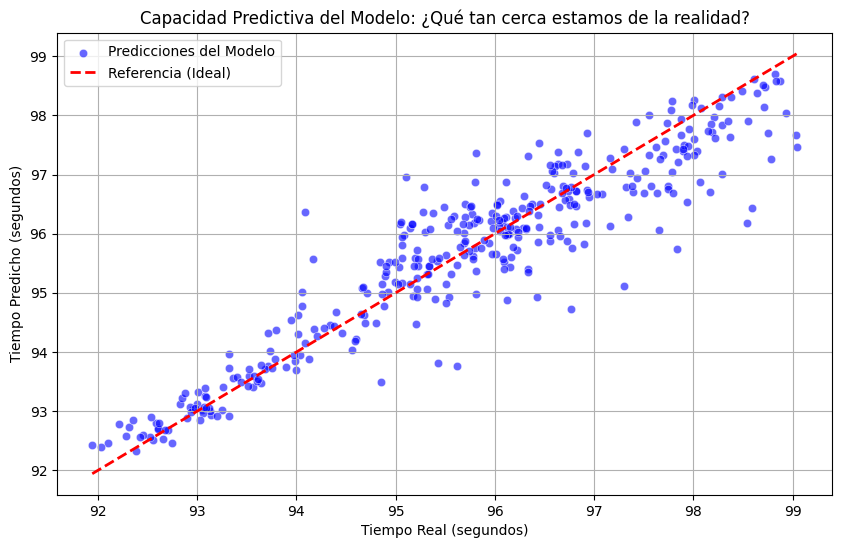

El modelo falla en promedio por: 0.440 segundos


In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt

# Dummies
X = df_ml.drop('LapTime', axis=1)
y = df_ml['LapTime']

# Train Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training 
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

# Pred vs Real
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions, alpha=0.6, color='blue', label='Predicciones del Modelo')

# Regression
line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, '--r', lw=2, label='Referencia (Ideal)')

plt.title('Capacidad Predictiva del Modelo: ¿Qué tan cerca estamos de la realidad?')
plt.xlabel('Tiempo Real (segundos)')
plt.ylabel('Tiempo Predicho (segundos)')
plt.legend()
plt.grid(True)
plt.show()

error = mean_absolute_error(y_test, predictions)
print(f"El modelo falla en promedio por: {error:.3f} segundos")

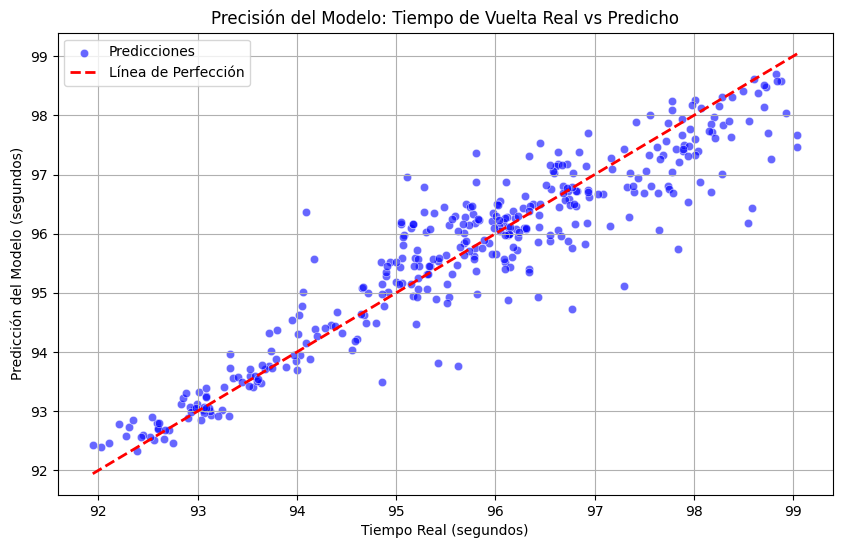

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot
sns.scatterplot(x=y_test, y=predictions, alpha=0.6, color='blue', label='Predicciones')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2, label='Línea de Perfección')

plt.title('Precisión del Modelo: Tiempo de Vuelta Real vs Predicho')
plt.xlabel('Tiempo Real (segundos)')
plt.ylabel('Predicción del Modelo (segundos)')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_24764\428753095.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')


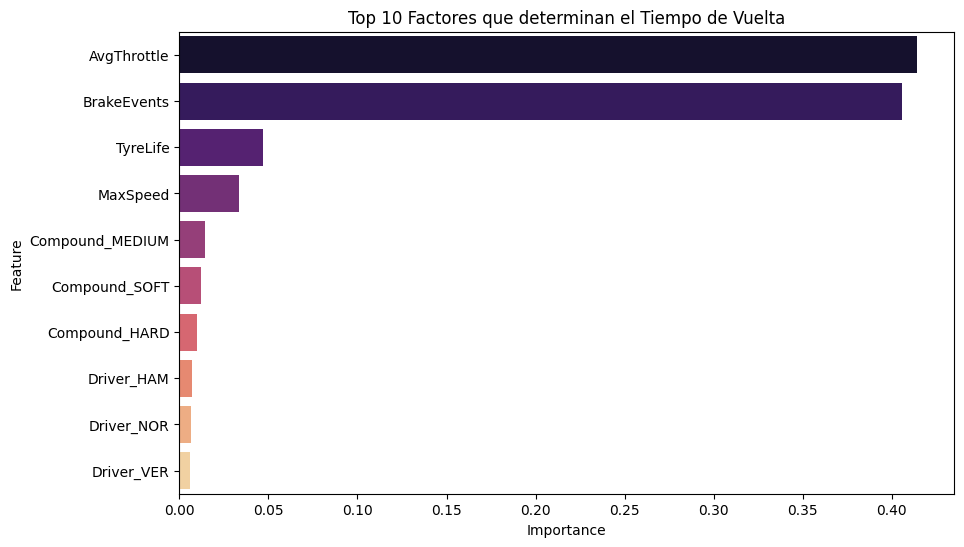

In [20]:

importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Graf
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')
plt.title('Top 10 Factores que determinan el Tiempo de Vuelta')
plt.show()